# Librerías y configuración inicial

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_style("whitegrid")

# Carga de datos

In [2]:
current = Path.cwd()
file_path = current.parent / "data" / "preprocessed_data" / "preprocess_data.parquet"
if not file_path.exists():
    raise FileNotFoundError(f"[ERROR] No se encontró el archivo: {file_path}")

df = pd.read_parquet(file_path)
df = df.sort_values("datetime") # Ordenamos por si acaso

# Calidad y estructura del dataset

In [3]:
print("Información general del dataset:\n")
df.info()

Información general del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61368 entries, 0 to 61367
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype                        
---  ------                        --------------  -----                        
 0   datetime                      61368 non-null  datetime64[ns, Europe/Madrid]
 1   demanda                       61368 non-null  float64                      
 2   precio                        61368 non-null  float64                      
 3   energia_mercado               59147 non-null  float64                      
 4   gen_carbon                    61368 non-null  float64                      
 5   gen_ciclo_combinado           61368 non-null  float64                      
 6   gen_cogeneracion              61368 non-null  float64                      
 7   gen_eolica                    61368 non-null  float64                      
 8   gen_fuel_gas                  61368 non-nu

In [4]:
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


In [5]:
df.isna().sum()

datetime                           0
demanda                            0
precio                             0
energia_mercado                 2221
gen_carbon                         0
gen_ciclo_combinado                0
gen_cogeneracion                   0
gen_eolica                         0
gen_fuel_gas                       0
gen_hidraulica                     0
gen_nuclear                        0
gen_otras_renovables               0
gen_residuos_no_renovables         0
gen_residuos_renovables            0
gen_solar_fotovoltaica             0
gen_solar_termica                  0
gen_turbina_vapor                  0
casada_carbon                   7410
casada_nuclear                  7410
casada_hidraulica               7410
casada_ciclo_combinado          7410
casada_eolica                   7410
casada_solar_termica            7410
casada_solar_fotovoltaica       7410
casada_residuos                 7410
casada_importacion              7410
casada_importacion_sin_mibel    7410
a

In [6]:
print("Fecha inicio:", df['datetime'].min())
print("Fecha fin:", df['datetime'].max())

Fecha inicio: 2019-01-01 00:00:00+01:00
Fecha fin: 2025-12-31 23:00:00+01:00


In [7]:
expected_range = pd.date_range(start=df["datetime"].min(), end=df["datetime"].max(), freq="h", tz=df["datetime"].dt.tz)
missing_dates  = expected_range.difference(df["datetime"])
print("Fechas faltantes:", len(missing_dates))

Fechas faltantes: 0


In [8]:
df.sample(5)

,datetime,demanda,precio,energia_mercado,gen_carbon,gen_ciclo_combinado,gen_cogeneracion,gen_eolica,gen_fuel_gas,gen_hidraulica,...,alm_entrega_bateria,alm_turbinacion_bombeo,andorra_export,andorra_import,francia_export,francia_import,marruecos_export,marruecos_import,portugal_export,portugal_import
25272,2021-11-19 00:00:00+01:00,26153.936,220.05,23944.8,810.266708,9525.656833,3201.981667,6429.355708,-0.000042,1920.481417,...,0.000000,190.220708,-42.727917,0.00000,-1488.506125,142.231625,-67.875000,49.812500,-244.177042,1618.710208
55851,2025-05-16 04:00:00+02:00,21560.089,3.28,20227.8,198.724750,3077.533333,1451.719375,6555.663875,0.000000,5132.534583,...,1.216458,665.934125,-12.333750,0.00875,-1515.156083,58.249917,-743.283000,0.000000,-1120.697333,445.819000
11580,2020-04-27 13:00:00+02:00,27685.254,20.39,24324.4,328.993167,2068.145000,2908.295542,4784.813125,0.000042,6108.197708,...,0.000000,305.329708,-7.260833,0.00000,-580.557083,342.777667,-50.212500,20.850000,-584.629167,739.842500
18682,2021-02-17 10:00:00+01:00,33674.460,56.10,28145.8,517.438167,1866.321500,3198.378292,6248.081750,0.000042,7376.979000,...,0.000000,857.185958,-40.004167,0.00000,-1221.394417,207.915208,-1.820833,1.241667,-69.640375,2087.056458
7724,2019-11-18 20:00:00+01:00,36746.363,62.55,35409.7,873.764208,8319.147208,3618.584375,7380.836500,-0.000042,4090.572333,...,0.000000,226.262667,-30.387917,0.00000,-1216.861167,455.800458,-0.183333,228.008333,-484.953250,1007.932708


# Análisis descriptivo univariante

In [9]:
# Calculamos describe y guardamos las columnas para ordenar más adelante
desc = df.describe().T
cols = desc.columns.tolist()

# Añadimos coeficiente de variación (cv) en formato de porcentaje, y asimetría (skewness) para comprobar distribución
desc['cv']   = (desc['std'] / desc['mean']) * 100
desc['skew'] = df.skew(numeric_only=True)

# Ordenamos las columnas
cols.insert(cols.index('std') + 1, 'cv')
cols.insert(cols.index('std') + 2, 'skew')
desc = desc[cols]

desc

,count,mean,std,cv,skew,min,25%,50%,75%,max
demanda,61368.0,27203.185580,4390.419653,16.139359,0.106912,522.770000,23632.220750,27229.505000,30487.717250,41483.001000
precio,61368.0,82.185970,64.353286,78.302034,1.476862,-15.000000,38.100000,64.235000,112.820000,700.000000
energia_mercado,59147.0,24532.586785,4505.361749,18.364805,0.184508,13107.300000,21010.800000,24373.500000,27847.800000,39938.700000
gen_carbon,61368.0,593.373621,632.243237,106.550614,4.440193,-51.460375,284.021833,432.790125,721.442958,6123.023375
gen_ciclo_combinado,61368.0,4814.530446,2783.045363,57.805125,1.056092,713.569167,2692.139167,4112.060292,6433.390958,15379.690792
gen_cogeneracion,61368.0,2435.163383,758.730924,31.157290,-0.220514,718.223708,1831.523958,2471.238167,3115.328708,3829.508792
gen_eolica,61368.0,6586.423419,3522.068221,53.474671,0.810896,687.061292,3877.727250,5820.923167,8648.612792,18327.099542
gen_fuel_gas,61368.0,0.000007,0.000036,486.727608,-0.347398,-0.000042,-0.000042,0.000000,0.000042,0.000042
gen_hidraulica,61368.0,3214.395328,1567.810892,48.774676,0.755956,531.184667,2020.871125,2869.792125,4163.190542,8147.816875
gen_nuclear,61368.0,6199.322886,991.098281,15.987202,-1.236623,6.330375,5621.045708,6695.486000,6979.109583,7139.537917


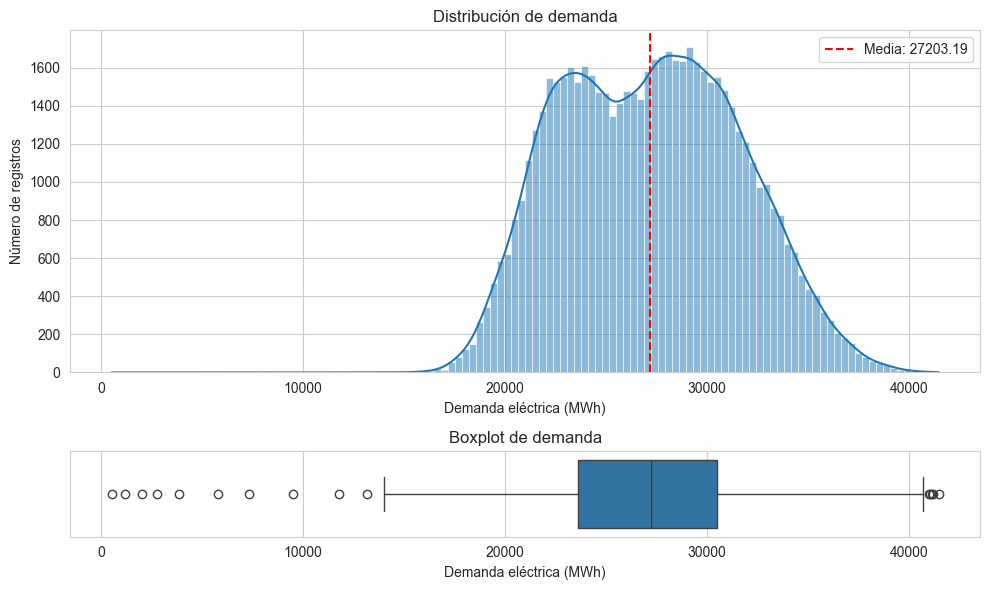

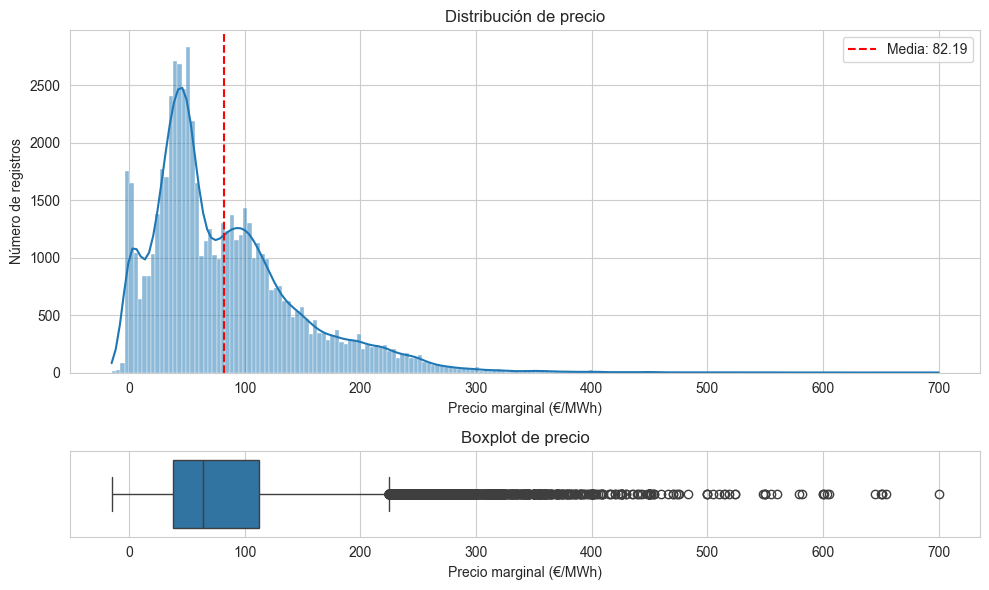

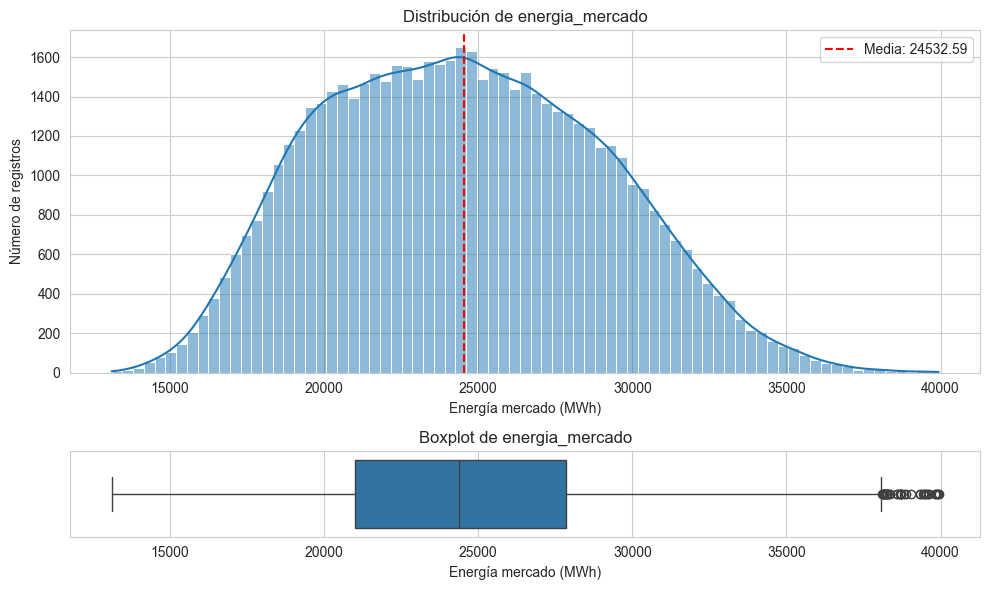

In [10]:
variables = {
    "demanda"         : "Demanda eléctrica (MWh)",
    "precio"          : "Precio marginal (€/MWh)",
    "energia_mercado" : "Energía mercado (MWh)"
}

for col, label in variables.items():

    fig, axes = plt.subplots(2, 1, figsize=(10,6), gridspec_kw={"height_ratios": [4, 1]})

    # Histograma con curva KDE (Kernel Density Estimate)
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
    axes[0].axvline(df[col].mean(), color="red", linestyle="--", label=f"Media: {df[col].mean():.2f}")
    axes[0].set_title(f"Distribución de {col}")
    axes[0].set_xlabel(label)
    axes[0].set_ylabel("Número de registros")
    axes[0].legend()

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot de {col}")
    axes[1].set_xlabel(label)

    plt.tight_layout()
    plt.show()

# Evolución temporal

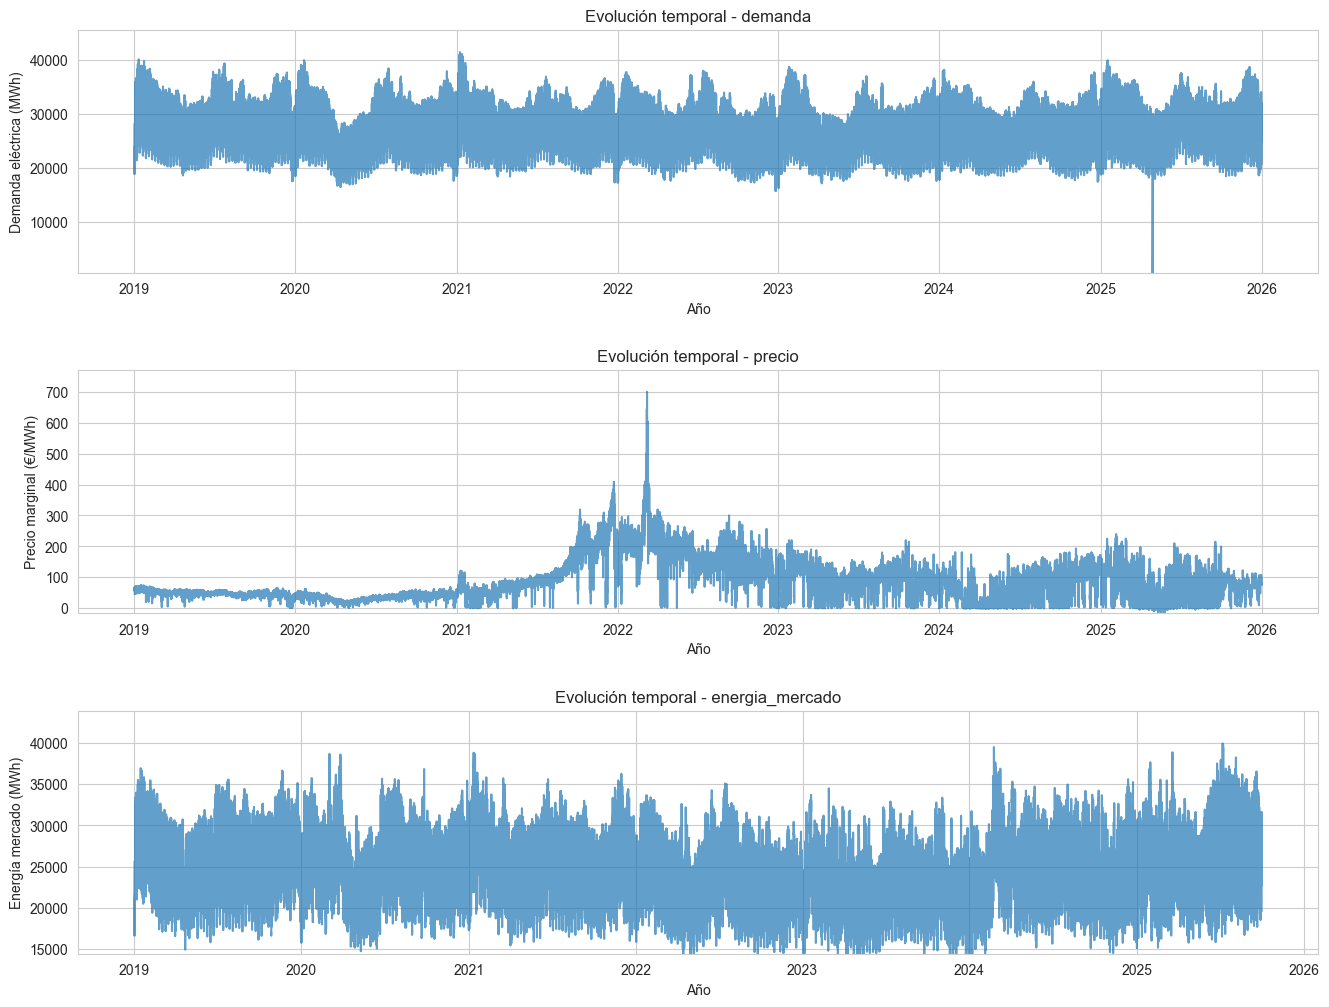

In [11]:
variables = {
    "demanda"         : "Demanda eléctrica (MWh)",
    "precio"          : "Precio marginal (€/MWh)",
    "energia_mercado" : "Energía mercado (MWh)"
}

fig, axes = plt.subplots(len(variables), 1, figsize=(16,12))

for i, (var, label) in enumerate(variables.items()):

    axes[i].plot(df['datetime'], df[var], alpha=0.7)
    axes[i].set_title(f"Evolución temporal - {var}")
    axes[i].set_ylabel(label)
    axes[i].set_xlabel("Año")

    ymin = df[var].min() * 1.1
    ymax = df[var].max() * 1.1

    axes[i].set_ylim(ymin, ymax)

plt.subplots_adjust(hspace=0.4) # Más espacio vertical entre las gráficas
plt.show()

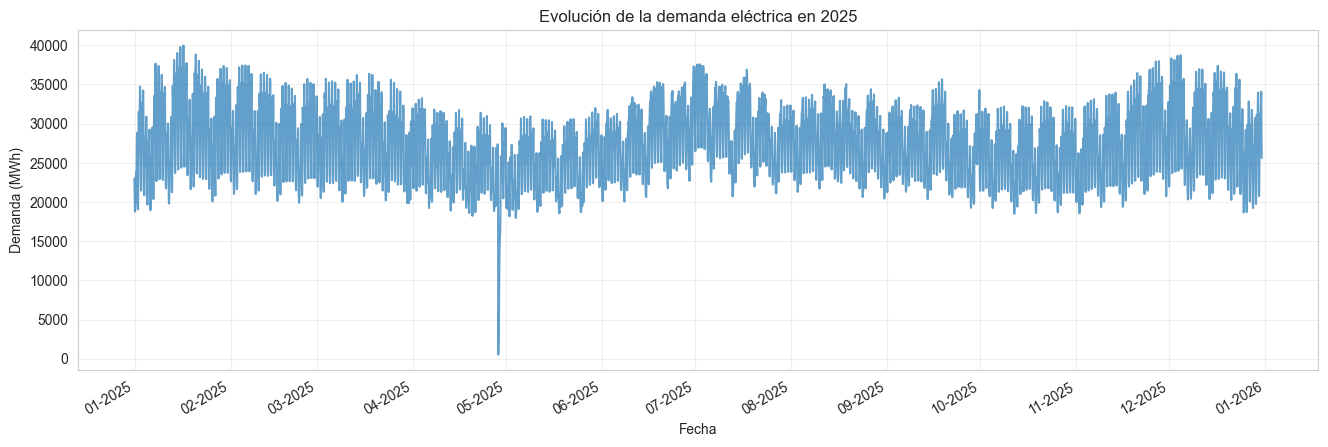

In [12]:
# Zoom a la evolución de la demanda en el año 2025
df_zoom_demanda = df[(df['datetime'] >= '2025-01-01') & (df['datetime'] <= '2025-12-31')]

plt.figure(figsize=(16,5))
plt.plot(df_zoom_demanda['datetime'], df_zoom_demanda['demanda'], alpha=0.7)

plt.title("Evolución de la demanda eléctrica en 2025")
plt.xlabel("Fecha")
plt.ylabel("Demanda (MWh)")

# Para mostrar todos los meses en el eje X en formato mes-año
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))

plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

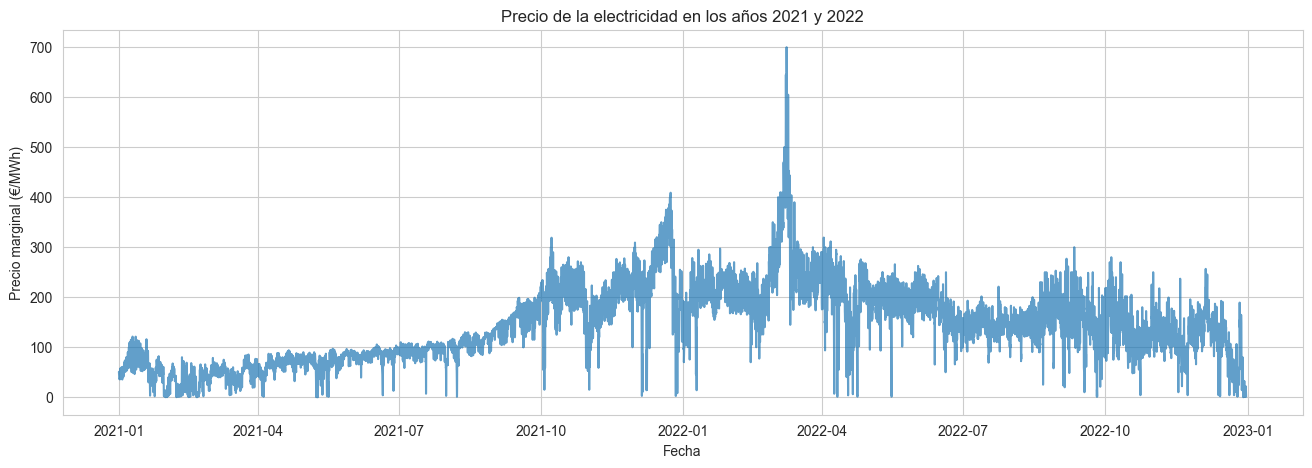

In [13]:
# Zooom a la evolución del precio en el rango 2021-2022
df_zoom_precio = df[(df['datetime'] >= '2021-01-01') & (df['datetime'] <= '2022-12-31')]

plt.figure(figsize=(16,5))
plt.plot(df_zoom_precio['datetime'], df_zoom_precio['precio'], alpha=0.7)
plt.title("Precio de la electricidad en los años 2021 y 2022")
plt.xlabel("Fecha")
plt.ylabel("Precio marginal (€/MWh)")

plt.show()

In [14]:
def perfil_temporal(df, periodo):
    # La configuración dependerá del periodo escogido
    if periodo == 'hora':
     
        df['periodo'] = df['datetime'].dt.hour
        orden  = list(range(24))
        xlabel = "Hora del día"
        titulo = "Perfil medio horario"
 
    elif periodo == 'semana':

        orden = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
        map   = {
            'Monday'    : 'Lunes',
            'Tuesday'   : 'Martes',
            'Wednesday' : 'Miércoles',
            'Thursday'  : 'Jueves',
            'Friday'    : 'Viernes',
            'Saturday'  : 'Sábado',
            'Sunday'    : 'Domingo'
        }

        df['periodo'] = df['datetime'].dt.day_name().map(map)
        df['periodo'] = pd.Categorical(df['periodo'], categories=orden, ordered=True)

        xlabel = "Día de la semana"
        titulo = "Perfil medio semanal"

    else: # periodo == 'mes'

        orden = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
        map   = {
            1  : 'Enero',
            2  : 'Febrero',
            3  : 'Marzo',
            4  : 'Abril',
            5  : 'Mayo',
            6  : 'Junio',
            7  : 'Julio',
            8  : 'Agosto',
            9  : 'Septiembre',
            10 : 'Octubre',
            11 : 'Noviembre',
            12 : 'Diciembre'
        }

        df['periodo'] = df['datetime'].dt.month.map(map)
        df['periodo'] = pd.Categorical(df['periodo'], categories=orden, ordered=True)

        orden  = orden
        xlabel = "Mes"
        titulo = "Perfil medio mensual"

    # Agrupamos por el periodo y graficamos
    df_periodo = df.groupby('periodo', observed=False)[['demanda', 'precio']].mean().reindex(orden)

    fig, ax1 = plt.subplots(figsize=(12,5))

    # Demanda
    line1 = ax1.plot(df_periodo.index, df_periodo['demanda'], color='tab:blue', linewidth=2, label='Demanda')
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel("Demanda eléctrica (MWh)", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    if periodo == 'hora':
        ax1.set_xticks(range(24))

    # Precio
    ax2 = ax1.twinx()
    line2 = ax2.plot(df_periodo.index, df_periodo['precio'], color='tab:red', linestyle='--', linewidth=2, label='Precio')
    ax2.set_ylabel("Precio marginal (€/MWh)", color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    # Leyenda
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

    plt.title(titulo)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


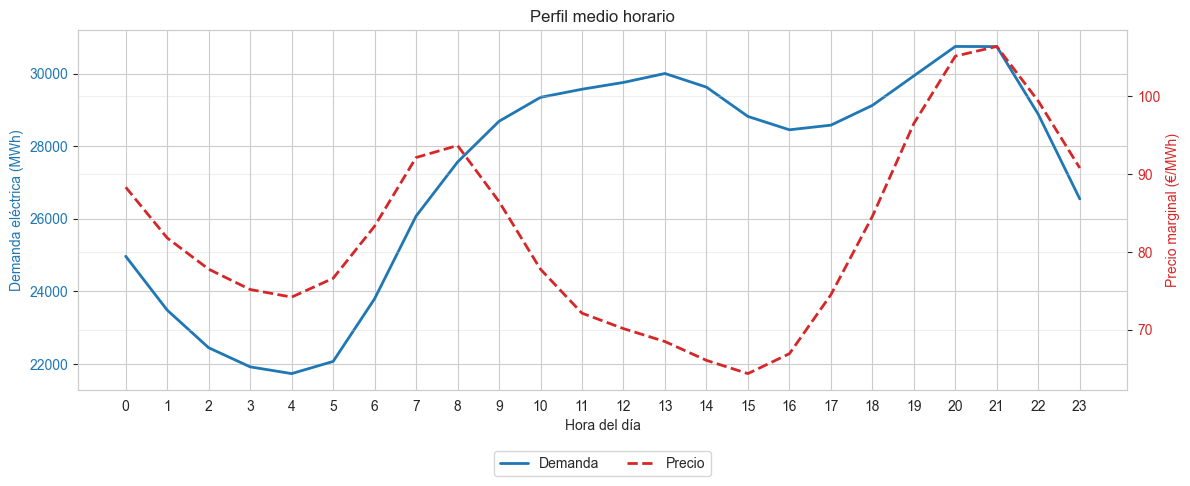

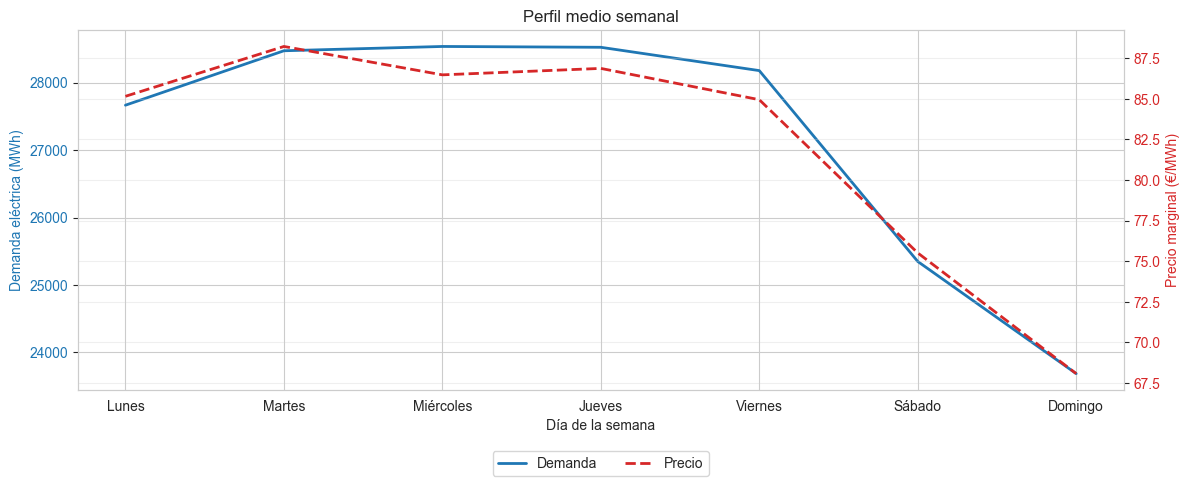

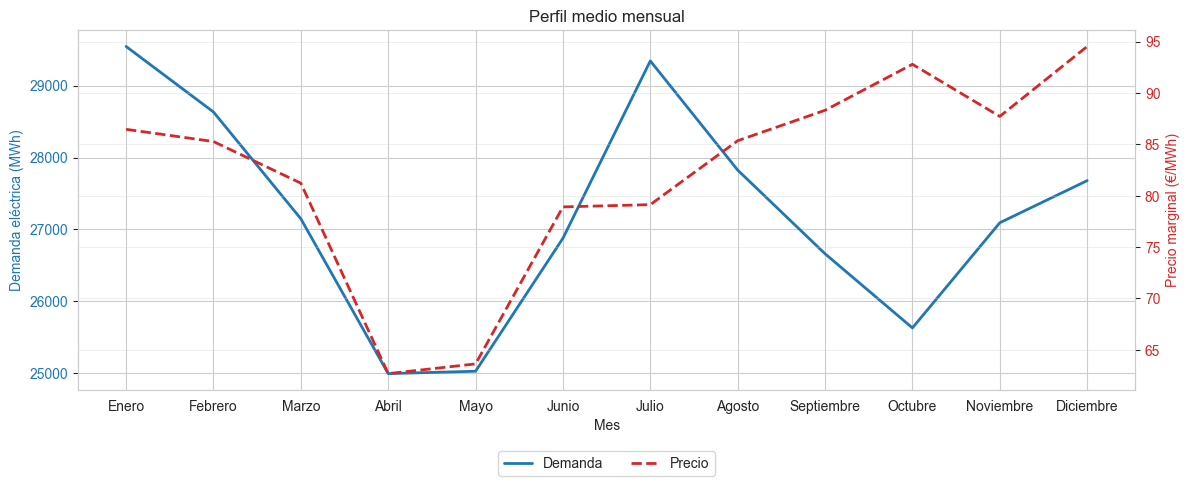

In [15]:
perfil_temporal(df.copy(), 'hora')
perfil_temporal(df.copy(), 'semana')
perfil_temporal(df.copy(), 'mes')

In [16]:
def plot_heatmap_mensual_horario(df, variable):

    orden = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
    map   = {
        1: 'Enero',
        2: 'Febrero',
        3: 'Marzo',
        4: 'Abril',
        5: 'Mayo',
        6: 'Junio',
        7: 'Julio',
        8: 'Agosto',
        9: 'Septiembre',
        10: 'Octubre',
        11: 'Noviembre',
        12: 'Diciembre'
    }

    unidades = {
        'demanda' : 'Demanda eléctrica (MWh)',
        'precio'  : 'Precio marginal (€/MWh)'
    }

    df_heat = df.copy()
    df_heat['hora'] = df_heat['datetime'].dt.hour
    df_heat['mes']  = df_heat['datetime'].dt.month.map(map)
    df_heat['mes']  = pd.Categorical(df_heat['mes'], categories=orden, ordered=True)

    pivot = df_heat.pivot_table(values=variable, index='mes', columns='hora', aggfunc='mean', observed=False)

    plt.figure(figsize=(16,6))

    sns.heatmap(pivot, cmap='RdYlBu_r', cbar_kws={'label': unidades[variable]})

    plt.title(f"Heatmap mes/hora - {variable}")
    plt.xlabel("Hora del día")
    plt.ylabel("Mes")

    plt.show()

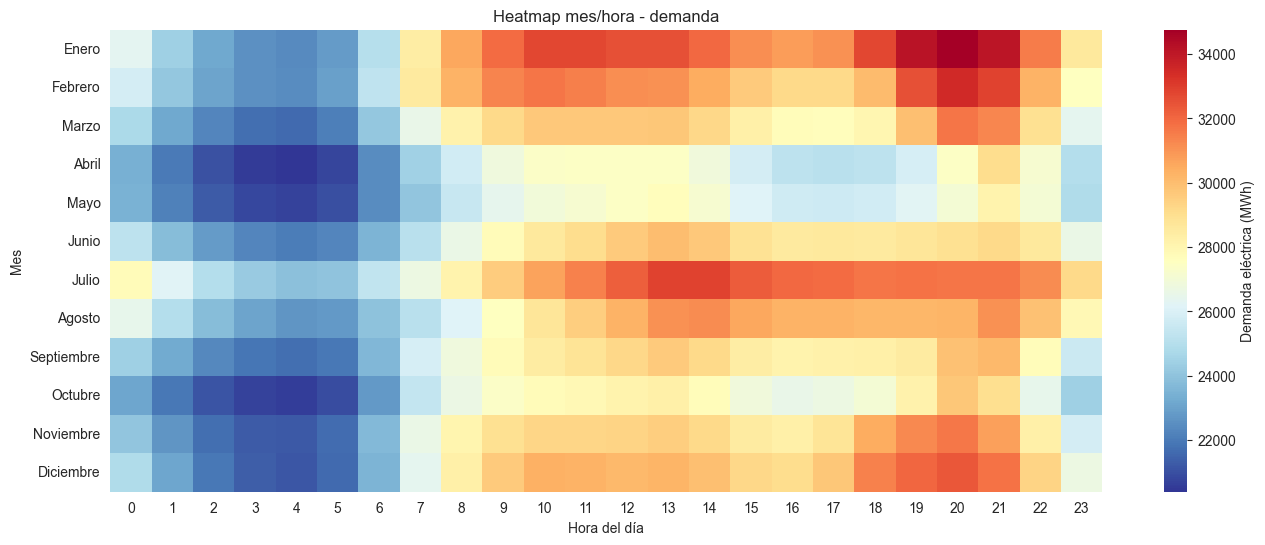

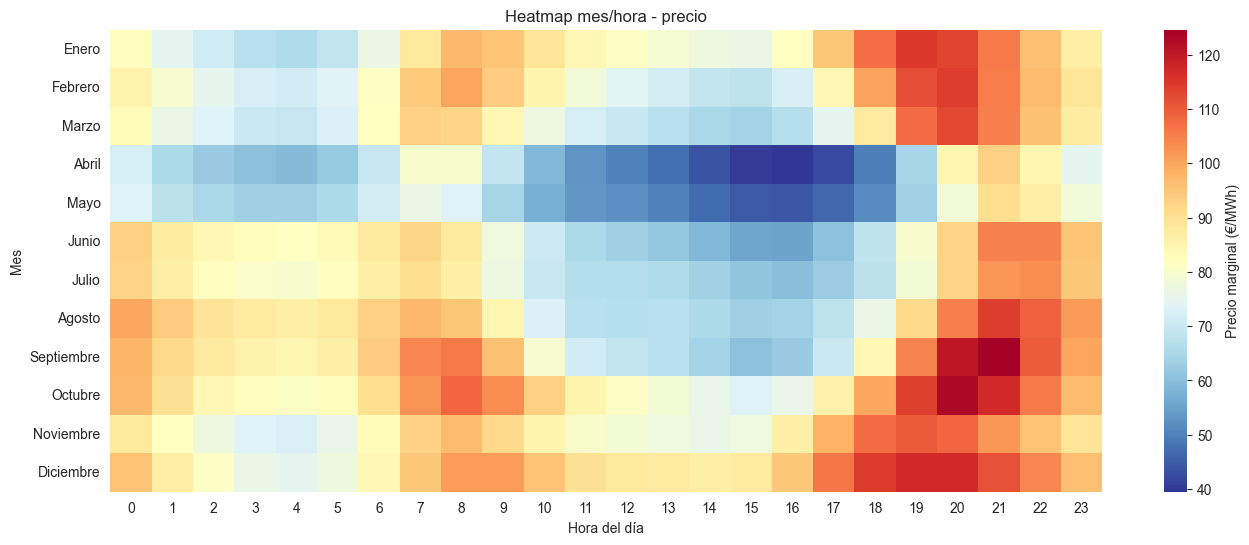

In [17]:
plot_heatmap_mensual_horario(df, 'demanda')
plot_heatmap_mensual_horario(df, 'precio')

# Análisis de correlaciones

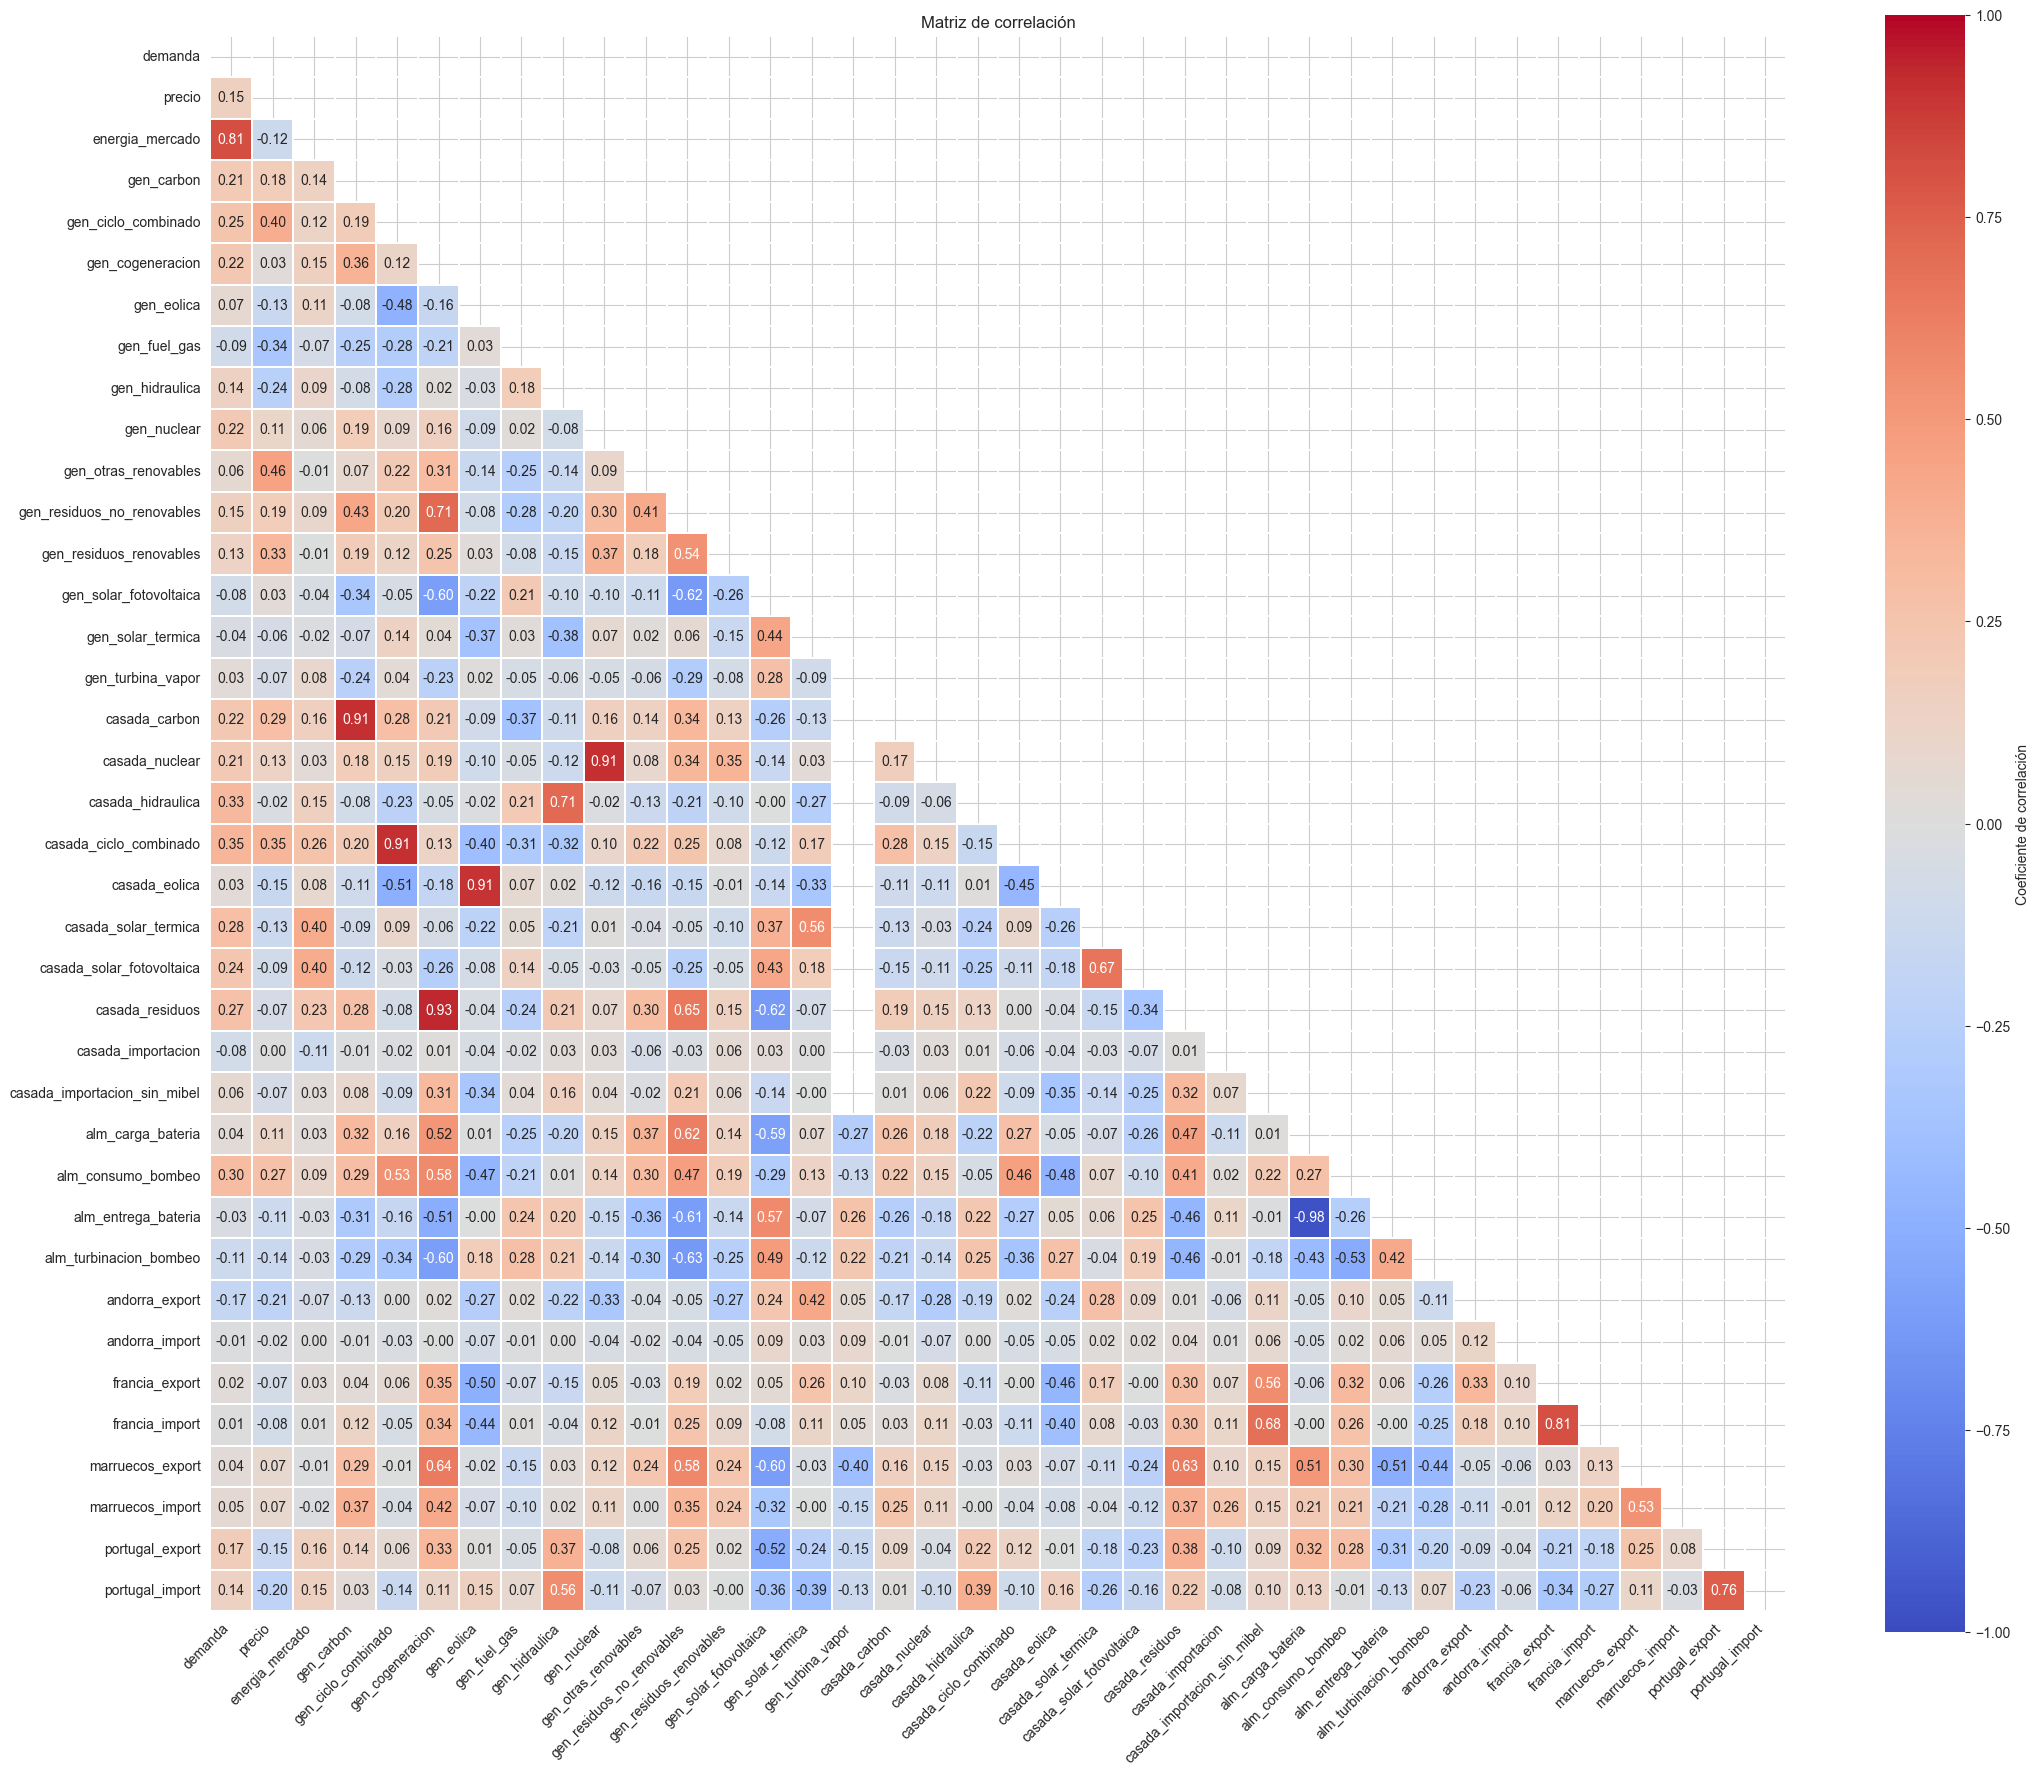

In [18]:
# Generamos la matriz de correlación y, a partir de ella, crearemos un heatmap para un análisis visual
corr = df.corr(numeric_only=True)

# Aplicamos una máscara triangular (mejor visualmente, no repetimos recuadros)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(22,18))

sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.3, square=True, annot=True, fmt=".2f", 
    annot_kws={"size":10}, cbar_kws={'label': 'Coeficiente de correlación'}
)

plt.title("Matriz de correlación")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [19]:
print(corr['demanda'].drop('demanda').sort_values(ascending=False))

energia_mercado                 0.813536
casada_ciclo_combinado          0.349011
casada_hidraulica               0.325705
alm_consumo_bombeo              0.298358
casada_solar_termica            0.283183
casada_residuos                 0.267705
gen_ciclo_combinado             0.249381
casada_solar_fotovoltaica       0.236822
casada_carbon                   0.221588
gen_cogeneracion                0.221583
gen_nuclear                     0.216813
casada_nuclear                  0.212113
gen_carbon                      0.206337
portugal_export                 0.173935
gen_residuos_no_renovables      0.153269
precio                          0.152699
portugal_import                 0.141660
gen_hidraulica                  0.137943
gen_residuos_renovables         0.128036
gen_eolica                      0.065459
gen_otras_renovables            0.063030
casada_importacion_sin_mibel    0.062846
marruecos_import                0.054862
alm_carga_bateria               0.037765
marruecos_export

In [20]:
print(corr['precio'].drop('precio').sort_values(ascending=False))

gen_otras_renovables            0.460081
gen_ciclo_combinado             0.395214
casada_ciclo_combinado          0.349136
gen_residuos_renovables         0.329259
casada_carbon                   0.288916
alm_consumo_bombeo              0.266684
gen_residuos_no_renovables      0.187373
gen_carbon                      0.180424
demanda                         0.152699
casada_nuclear                  0.130648
alm_carga_bateria               0.114809
gen_nuclear                     0.105470
marruecos_import                0.072484
marruecos_export                0.071103
gen_solar_fotovoltaica          0.034486
gen_cogeneracion                0.031153
casada_importacion              0.003043
andorra_import                 -0.021415
casada_hidraulica              -0.024955
gen_solar_termica              -0.063878
gen_turbina_vapor              -0.066187
casada_residuos                -0.068948
casada_importacion_sin_mibel   -0.069777
francia_export                 -0.071788
francia_import  

# Análisis de autocorrelación temporal (ACF y PACF)

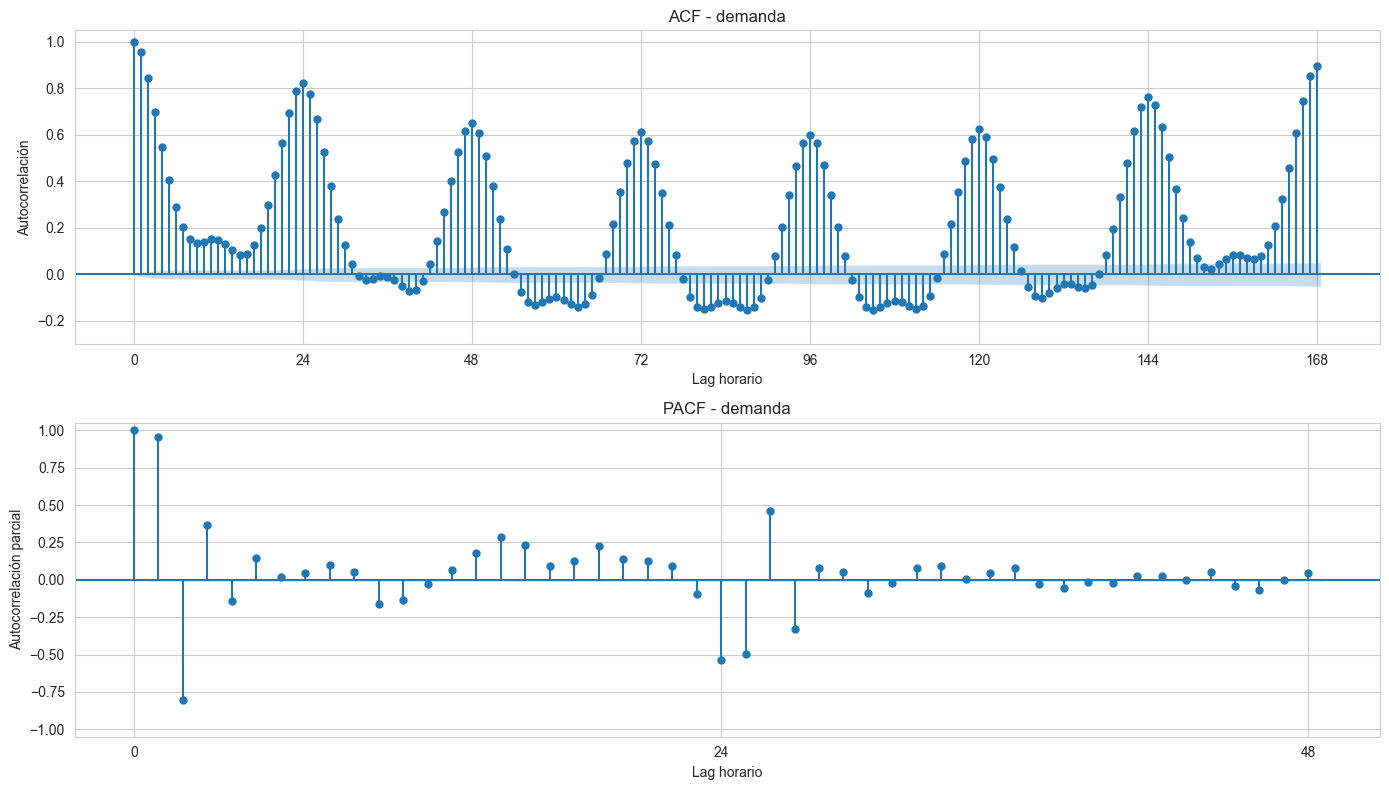

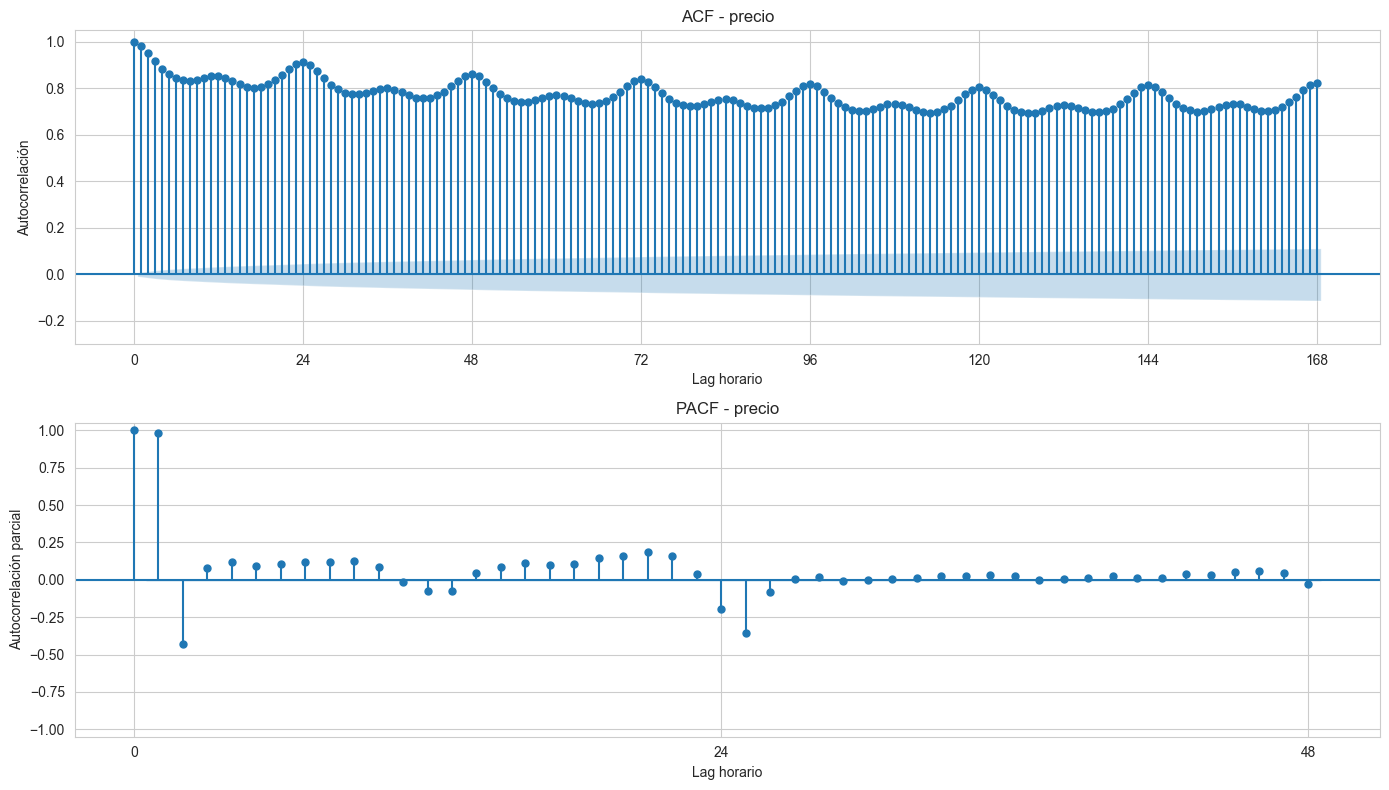

In [21]:
for var in ['demanda', 'precio']:

    fig, axes = plt.subplots(2, 1, figsize=(14,8))

    # ACF
    plot_acf(df[var].dropna(), lags=168, ax=axes[0])

    axes[0].set_title(f"ACF - {var}")
    axes[0].set_xlabel("Lag horario")
    axes[0].set_ylabel("Autocorrelación")
    axes[0].set_ylim(-0.3, 1.05)
    axes[0].set_xticks(range(0, 169, 24))

    # PACF
    plot_pacf(df[var].dropna(), lags=48, ax=axes[1], method='ywm')

    axes[1].set_title(f"PACF - {var}")
    axes[1].set_xlabel("Lag horario")
    axes[1].set_ylabel("Autocorrelación parcial")
    axes[1].set_ylim(-1.05, 1.05)
    axes[1].set_xticks(range(0, 49, 24))

    plt.tight_layout()
    plt.show()